CIFAR-10 Image Classification


In [27]:
#Import the required Torch packages
import torch
import torchvision
import torchvision.transforms as transforms

#
transform=transforms.Compose(                                 # transforms.Compose -> This simply chains multiple transformations together
    [transforms.ToTensor(),                                   # First: Convert Image -> Tensor, does 2 things : vonverts images to pytorch tensors and scales pixel values from[0,255] ->[0,1]
     transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))]       # Second: Normalize the Tensor , normalizes each color channel (R, G, B). Final range becomes [-1,1]
)
# Why do we normalize?
# To center data around 0,Helps neural networks train faster,Improves numerical stability

trainset=torchvision.datasets.CIFAR10(root='/.data',train=True,download=True,transform=transform)
testset=torchvision.datasets.CIFAR10(root='/.data',train=False,download=True,transform=transform)

classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

In [28]:
# We will feed our data in batches , so we need to generate train and test loaders
batch_size=5
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True,num_workers=2)
testloader=torch.utils.data.DataLoader(testset,batch_size=batch_size,shuffle=False,num_workers=2)

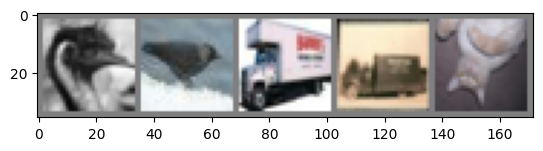

 bird birdtrucktruck  cat


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# function to show an image

def imshow(img):
  img=img/2+0.5 #unnormalize
  npimg=img.numpy()   # converts pytorch tensor -> numpy , required becuase matplot works with numpy
  plt.imshow(np.transpose(npimg,(1,2,0)))  # rearrange the dimension from pytorch image format(C,H,W) to matplot expected format (H,W,C)
  plt.show()

#get random training image
dataiter=iter(trainloader)  # creates an iterator over the data loader
images,labels =next(dataiter)

#show image
imshow(torchvision.utils.make_grid(images))  # takes multiple images and puts them into a grid

#print labels
print(''.join('%5s' % classes[labels[j]] for j in range(batch_size)))






In [30]:
# Lets build our Nueral Network and CNN for image classification
import torch
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,10,5),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(10,16,5),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*5*5,84),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(84,10),
        )

    # ✅ SAME LEVEL as __init__
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [31]:
# device set up
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
#training our model
def train(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()   # counts the correct predictions


    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy

In [33]:
# Now we will evaluate our model
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():   # IMPORTANT
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / len(loader.dataset)

    return avg_loss, accuracy




In [35]:
# Run your model
for epoch in range(1,6):
  train_loss,train_acc=train(model,trainloader,criterion,optimizer,device)
  test_loss,test_acc=evaluate(model,testloader,criterion,device)
  print(f"Epoch {epoch} | Train {train_acc:.1f}% | Test {test_acc:.1f}%")

Epoch 1 | Train 47.4% | Test 53.6%
Epoch 2 | Train 50.6% | Test 55.6%
Epoch 3 | Train 51.7% | Test 54.9%
Epoch 4 | Train 53.5% | Test 55.6%
Epoch 5 | Train 54.3% | Test 56.2%
